#**Regression Course**


---

In this course, you will learn how to apply ***the supervised learning workflow (explained in Section 4 of the lecture) to regression problems***. We will use **linear regression model** throughout the exercises and look at each step of the workflow: ***understanding the data, processing data, model building, and model evaluation***.The goal is to practice the knowledge required for each step depending on the level.

#Level 4（★★★★）





---
In Level 4, we’ll learn how to train a model and make predictions using standardized data.

##4.1. Preprocessing Data

As before, download the `Car_Price_Data.csv` using the link below, upload it to the designated location, read it into a DataFrame, and remove any missing values.

[Car_Price_Data.csv](https://drive.google.com/file/d/1YVQgy_jAwSVH5YEMdWlrTzkXEf7no860/view?usp=drive_link)

In [ ]:
import pandas as pd

df = pd.read_csv('Car_Price_Data.csv')
df = df.dropna()

For example, when the units or scales of the explanatory variables differ significantly, it becomes difficult to determine which variable has a greater impact on the predictions. If one variable is measured in kilograms and another in grams, the regression coefficients can be skewed due to the unit difference alone.

That’s why we use **standardization**, a type of numerical scaling. This process eliminates the influence of unit or range differences and helps the model interpret the data more accurately.

Standardization involves subtracting the mean from each data point and then dividing by the standard deviation. This transforms the features so that each one has a mean of 0 and a standard deviation of 1.

Here’s the formula we use:

\begin{equation}
x_{std} = \cfrac{x - \mu_x}{\sigma_x}
\end{equation}

where
* $x$: Data before standardization
* $x_{std}$: Data after standardization
* $\mu_x$: Mean of the data
* $\sigma_x$: Standard deviation of the data

To perform standardization, we’ll use the `StandardScaler` class from `sklearn.preprocessing`.

Let’s see how this works with the car price dataset we just loaded.

If you examine the means and standard deviations of the explanatory variables— `engine-size`, `curb-weight`, and `city-mpg` — you’ll notice that their scales differ significantly and are inconsistent. At this point, it's still difficult to properly interpret the model.

In [ ]:
df[['engine-size', 'curb-weight', 'city-mpg']].describe().loc[['mean', 'std']]

,engine-size,curb-weight,city-mpg
mean,126.875622,2555.666667,25.179104
std,41.546834,517.296727,6.423220


Now, let’s standardize these variables. The `fit()` method computes the mean and standard deviation for each column, and the `transform()` method applies these values to standardize the data.

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df[['engine-size', 'curb-weight', 'city-mpg']]

ss = StandardScaler()
ss.fit(X)
X_std = ss.transform(X)

# The line below is equivalent to the two lines above:
# X_std = ss.fit_transform(X)

df[['engine-size std', 'curb-weight std', 'city-mpg std']] = X_std

Let's check the mean and standar deviation of the standardized data.

In [ ]:
df[['engine-size std', 'curb-weight std', 'city-mpg std']].describe().loc[['mean', 'std']]

,engine-size std,curb-weight std,city-mpg std
mean,-3.755978e-17,3.004783e-16,5.302558e-17
std,1.002497e+00,1.002497e+00,1.002497e+00


Now that the data has been standardized, all features have a mean of 0 and a standard deviation of 1, meaning the scales are now aligned. Although we didn’t remove outliers this time, it’s generally better to handle outliers before standardizing the data. That leads to more reliable results, since standardization can be  affected by extreme values.

Next, we’ll build a linear regression model. To see how standardization affects the explanatory variables, we’ll check the regression coefficients. Here’s an important point: you should apply fit only to the training data to compute the mean and standard deviation, and then use transform on both the training and test sets.  If you compute those statistics on the entire dataset and then transform both sets, you’ll unintentionally leak information from the test set into your model. This is called **data leakage**, and it can make your evaluation results unreliable.

To split the data into training and test sets, we use `X_train` and `X_test` for the explanatory variables, and `y_train` and `y_test` for the target variable. The variable `X` contains the explanatory variables, and `y` contains the target variable. We use the `train_test_split()` function to divide them into training and test sets.

By default, `train_test_split()` funtion divides the data into training and test sets in a 3:1 ratio. However, in this case, we set `test_size = 0.2`, which splits the data in a 4:1 ratio. If you want to change this ratio, just adjust the `test_size` value in the `train_test_split()` function.

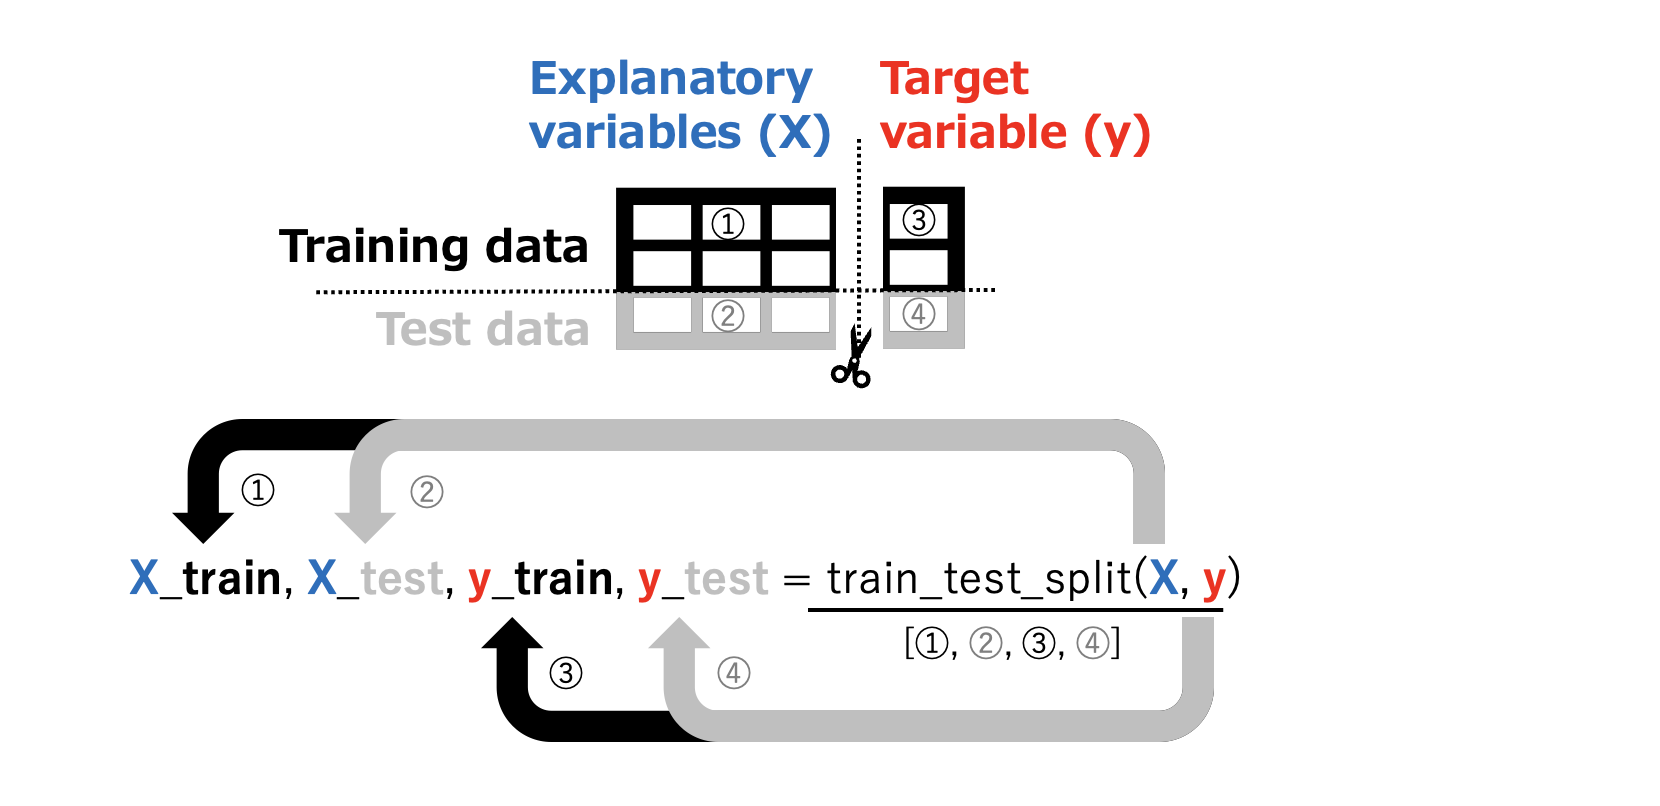

In [ ]:
from sklearn.model_selection import train_test_split

X = df[['engine-size', 'curb-weight', 'city-mpg']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ss = StandardScaler()
ss.fit(X_train)
X_train_std = ss.transform(X_train)
X_test_std = ss.transform(X_test)

##4.2. Model Building

First, let’s build a linear regression model using the data before standardization. As before, we use the `fit()` method to train the model.

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)
print('Regression Coefficients:', model.coef_)

Regression Coefficients: [  96.49537458    3.56641101 -152.03978154]


 It may appear that the third explanatory variable, `city-mpg`, contributes the most to the model’s prediction.  However, this interpretation is misleading because the variables are not on the same scale.

Now, let’s build a model using the standardized data.

In [ ]:
model = LinearRegression()
model.fit(X_train_std, y_train)
print('Regression Coefficients:', model.coef_)

Regression Coefficients: [3824.32832662 1748.78601005 -958.81499881]


Now that we’re using the standardized data, we can see that the first explanatory variable, `engine-size`, contributes the most to the model’s prediction. Since the variables are now on the same scale, we can compare the coefficients properly and begin interpreting the model accurately.

##4.3. Practice Problems

**Q4-1.** Download the file `Regression_Lv1_Practice.csv` used in Level 1, upload it, and read it into a pandas DataFrame.

[Regression_Lv1_Practice.csv](https://drive.google.com/file/d/1a21m4u-TWga-kUj6jy4Gbz6kvS6VlyZy/view?usp=drive_link)

Note that this dataset contains missing values, so please remove any rows with missing value first. After that, apply standardization to the explanatory variable `engine-size`.

**Q4-2.** Use `price` as the target variable and perform linear regression. Then, output the regression coefficients.